In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
from matplotlib import cm
#from matplotlib import norm
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')
import os

datadir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Relaxation/NEWData/Stretch102/'
datadirAlt  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_MonomerMeasurements/NEWData/'
plotsdir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Relaxation/Plots/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [2]:
def phiform(phi0,phi_inf,tau,t):
    if tau==0:
        phi = phi_inf
    else:
        phi = (phi0)*np.exp(-t/tau)+phi_inf
    return phi

def intersection(y,y0):
    diff = []
    for i in range(len(y)):
        #print(i)
        diff.append(float((y[i]-y0)*(y[i]-y0)))
    diff2 = sorted(diff)
    x = diff.index(diff2[0])
    return x,diff[x]

In [3]:
cmap0 = plt.cm.get_cmap('YlOrBr') #YlOrBr
clrs1= ['#edf8b1','#7fcdbb','#2c7fb8']
clrs2=['#f7fcb9','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['#e7e1ef','#c994c7','#dd1c77']

clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','dimgrey']
#clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']
clrs1= ['grey','#7fcdbb','#2c7fb8']
clrs2=['grey','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['grey','#c994c7','#dd1c77']
clrs_div = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
clrrrs=[clrs1,clrs3,clrs2]

#'YlOrBr'
ClrsRici = ["#96a2c1ff","#999ebeff","#a697baff","#b795afff","#c996a8ff","#d398a5ff"]
ClrsRici = ["#7883acff","#3e387bff","#73457aff","#a66181ff","#b25268ff","#d49995ff"]
ClrsRiciChosen = ["#7883acff","#73457aff","#b25268ff"] #
#ClrsRici =["#a66181ff","#d49995ff"] #ClrsRici  ClrsRici #["#7883acff","#73457aff","#b25268ff","#d49995ff"]
ClrsOrange = ["#fed98e","#fe9929","#d95f0e","#993404"]

[14.136435110367358, 16.914355090988998, 17.330893216723926, 26.142224446579256, 33.7174924816437, 62.94111858793398]


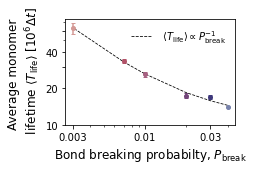

In [4]:
fig2,ax2 = plt.subplots(1,figsize = (3.5,2.3))

f=3
MP = "0.12 0.1 0.06 0.03 0.02 0.01".split() # ORIGINAL RANGE  0.12 0.1 0.06 0.03 0.02 0.01
BP = "0.04 0.03 0.02 0.01 0.007 0.003".split() # ORIGINAL RANGE 0.04 0.03 0.02 0.01 0.007 0.003
seeds= "1 3 5".split()
BPsV = [0.04,0.03,0.02,0.01,0.007,0.003]
AvTmonlife = []
StdTmonlife = []
AvLargestComps = []
for f in range(len(MP)):
    IndividualT_MonRelase = []
    LargestCompsEnd = []
    Tmonlife = []
    for s in range(len(seeds)):
        RateMons = []
        RateMonsRel = []
        RateMonsInc = []
        #Time NumMons RateMons LargestComp
        filename = 'monomerdata_BP'+BP[f]+'_S'+seeds[s]+'.dat'
        MonData = pandas.read_csv(datadirAlt+filename, header = 'infer',sep=' ')
        Time_ = MonData.Time
        NumMons_ = MonData.NumMons
        RateMons_ = MonData.RateMons
        LargestComp_ = MonData.LargestComp
        Time,NumMons,RateMons,LargestComp =Time_.values,NumMons_.values,RateMons_.values,LargestComp_.values
        if len(Time)>0:
            if Time[-1] >0.6e6:
                #for tt in range(len(Time)-1):
                #    RateMons.append((NumMons[tt+1]-NumMons[tt])/(Time[tt+1]-Time[tt]))
                AvNumMons = np.mean(NumMons[:]) #int(len(RateMons)/4)
                NumInNetwork = 6330-AvNumMons
                AverageT_MonRelease = np.divide(1,np.mean(np.abs(RateMons[:]))) #int(len(RateMons)/4)
                IndividualT_MonRelase.append(np.divide(AverageT_MonRelease * NumInNetwork,10**6))

                N=6
                rollingRatAv = np.convolve(np.abs(np.ravel(RateMons)), np.ones(N)/N, mode='valid')
                timeRol = Time[int(N/2)+1:-int(N/2-1)]
                idx = (np.abs(Time - 1509600)).argmin()
                LargestCompsEnd.append(LargestComp[idx])
                Tmonlife.append(IndividualT_MonRelase)
    AvTmonlife.append(np.mean(Tmonlife))
    StdTmonlife.append(np.std(Tmonlife))
    AvLargestComps.append(np.mean(LargestCompsEnd))
    ax2.errorbar(BPsV[f],np.mean(IndividualT_MonRelase),yerr = np.std(IndividualT_MonRelase),capsize = 2,color = ClrsRici[f],marker = 'o',markersize = 4) ##Would this by x2??
    #ax2.plot(BPsV[f],np.divide(np.mean(IndividualT_MonRelase),10**6),color = clrs_5[f],marker = 'o',markersize = 10) ##Would this by x2??
    #print(MP[f],np.mean(IndividualT_MonRelase),np.std(IndividualT_MonRelase))
#ax[2].set_ylabel("Free monomer lifetime",fontsize = 12)
ax2.set_ylabel("Average monomer \n lifetime"+r" $ \langle T_{\mathrm{life}}\rangle$ [$10^6\Delta t$]",fontsize = 12)
ax2.set_xlabel("Bond breaking probabilty, $P_{\mathrm{break}}$",fontsize = 12)
#ax2.set_yscale('log')
text = r" $ \langle T_{\mathrm{life}}\rangle \propto P_{\mathrm{break}}^{-1}$"
#ax2.set_ylim([0,350])
print(AvTmonlife)
fig2.tight_layout()
x1,y1 = np.array(np.divide(1,BPsV)),np.array(AvTmonlife)
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
ax2.plot(np.divide(1,x1),m1*x11+b1,color = 'black',linestyle = '--',linewidth = 0.8,label = text)
ax2.legend(fontsize = 10,loc = 'upper right',frameon=False)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_yticks([10,20,30,40,60],['10','20','','40',''])
ax2.set_xticks([0.003,0.01,0.03],['0.003','0.01','0.03'])
#ax.set_ylim([70,100])
plotname = "EquilibriumMaster.pdf"
#fig.savefig(plotsdir+plotname)

plotname2 = "MonomerExchangeMasterNEW.pdf"
#fig2.savefig(plotsdir+plotname2)
##plotname = "Equilibration_quants.pdf"


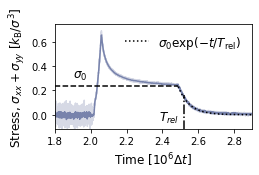

In [10]:
fig,ax = plt.subplots(1,figsize = (3.7,2.3))


xstretches = "102".split()
MPs = "0.03".split()
BPs = "0.01".split()

lenT0 = 101222
lenT1 = 3272

lenT0 = 101222
lenT1 = int(3272*1.8)


timeFactor = 10**6
t_Eq = (2000000*0.5)/timeFactor
t_MT = (2000000*0.5)/timeFactor +t_Eq
t_strain = ((40000+20000)/timeFactor)+t_MT
t_InitRel = 20000*20/timeFactor+t_strain
t_FulLRel = 1000000/timeFactor+t_InitRel

times = [0,t_Eq,t_MT,t_strain,t_InitRel,t_FulLRel]
UP,LW=-0.15,1.2
x=0
ax.set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
TmonAv = [1.7,2.6,6.2]
#Tmonstd = np.divide([3.571501191030219,5.480583457304206,13.19089058082929],10)
mrks = [":","-","--"]
alphs = [0.5,0.5,0.5]
Avtaus = []
Stdtaus = []
Vol1 = 51*51*12
Vol2 = (51+int(xstretches[x]))*(51+int(xstretches[x]))*12-Vol1
for p in range(len(MPs)):
    filename = 'stressdataK1_BP'+BPs[p]+'_Xstr102.dat'
    
    StressData = pandas.read_csv(datadir+filename, header = 'infer',sep=' ')
    Time_ = StressData.Time
    stressTotAv_ = StressData.stressAv
    stressTotAv,Time = stressTotAv_.values,Time_.values
    rollingAvRelax = np.convolve(stressTotAv[lenT0+lenT1:], np.ones(N)/N, mode='valid')
    timePostStretch = np.add(Time[lenT0+lenT1:],-Time[lenT0+lenT1])[int(N/2):-int(N/2-1)]
    stressPostStretch = rollingAvRelax
    ax.plot(timePostStretch,stressPostStretch,color = 'black')
    phi_inf = 0
    phi0 = stressPostStretch[10]
    phiTau = phi0/np.exp(1)
    tau = timePostStretch[intersection(stressPostStretch,phiTau)[0]]
    phiTheory = []
    for tt in range(len(timePostStretch)):
        t = timePostStretch[tt]
        phiTheory.append(phiform(phi0,phi_inf,tau,t))
    
    ax.plot(np.divide(Time,timeFactor),stressTotAv,color = ClrsRiciChosen[p],alpha =0.3)
    N=50
    rollingAv = np.convolve(stressTotAv, np.ones(N)/N, mode='valid')
        #rollingAvY = np.convolve(stressY, np.ones(N)/N, mode='valid')
    timeAv = Time[int(N/2):-int(N/2-1)]
            
    ax.plot(np.divide(timeAv,timeFactor),rollingAv,color = ClrsRiciChosen[p],linestyle = '-')
    #if p==2:
    ax.plot(np.divide(np.add(timePostStretch,Time[lenT0+lenT1]),timeFactor),phiTheory,linestyle = ':',color = 'black',label = r'$\sigma_{0} \exp({-t/T_{\mathrm{rel}}})$')
    # else:
    #     ax.plot(np.divide(np.add(timePostStretch,Time[lenT0+lenT1]),timeFactor),phiTheory,linestyle = ':',color = 'black')

    tauAxis = np.add(np.divide(tau,timeFactor),t_InitRel)
    ax.plot([tauAxis,tauAxis],[-0.13,0.16],linestyle = '-.',color = 'black')
    ax.plot([0,2.49],[phi0,phi0],linestyle = '--',color = 'black')
    #print(t_strain)
    # if p==0:
    #     ax.plot([tauAxis,tauAxis],[-0.13,0.04],linestyle = '-.',color = 'black')
    # if p==1:
    #     ax.plot([tauAxis,tauAxis],[-0.13,0.09],linestyle = '-.',color = 'black')
    # if p==2:
    #     
text2 = r"$T_{rel}$"
text3 = r"$\sigma_{0}$"
ax.text(2.38,-0.05,text2,color = 'black',fontsize = 12)
ax.text(1.9,0.3,text3,color = 'black',fontsize = 12)
ax.set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax.set_xlim([1.8,2.9])
ax.set_ylim([-0.12,0.75])
ax.legend(frameon=False,loc = [0.33,0.7],fontsize = 12)
fig.tight_layout()
plotname = "Stress_relaxationNEW_longInitRel.pdf"
fig.savefig(plotsdir + plotname)